# 1D Heat Transfer Modeling

I built this notebook to see how thermal diffusivity changes the way heat moves through a material. The model solves the one-dimensional heat equation with an explicit finite-difference method and fixed temperatures at the boundaries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Model parameters
L = 1.0                 # rod length (m)
alpha = 1.2e-4          # thermal diffusivity (m^2/s)
nx = 101                # number of spatial grid points
x = np.linspace(0, L, nx)
dx = x[1] - x[0]
t_final = 30.0          # total simulation time (s)
# Explicit method stability condition: r = alpha*dt/dx^2 <= 0.5
dt = 0.35 * dx**2 / alpha
nt = int(np.ceil(t_final / dt))
dt = t_final / nt
r = alpha * dt / dx**2
print(f'dx = {dx:.5f}, dt = {dt:.5f}, r = {r:.4f}, nt = {nt}')
if r > 0.5:
    raise ValueError('Scheme is unstable. Reduce dt or increase dx.')

dx = 0.01000, dt = 0.29126, r = 0.3495, nt = 103


In [2]:
# Initial and boundary conditions
T_left = 100.0          # left boundary temperature (deg C)
T_right = 25.0          # right boundary temperature (deg C)
# Initial profile: cool rod with a warm Gaussian bump near the center
T = 25.0 + 50.0 * np.exp(-((x - 0.5 * L) ** 2) / (2 * (0.08 * L) ** 2))
T[0] = T_left
T[-1] = T_right
# Times saved for plotting
save_times = [0.0, 2.0, 5.0, 10.0, 20.0, 30.0]
snapshots = {0.0: T.copy()}

In [3]:
# Explicit time stepping
Tn = T.copy()
time_grid = np.linspace(0, t_final, nt + 1)
for n in range(1, nt + 1):
    T_new = Tn.copy()
    T_new[1:-1] = Tn[1:-1] + r * (Tn[2:] - 2.0 * Tn[1:-1] + Tn[:-2])
    # Fixed boundary temperatures
    T_new[0] = T_left
    T_new[-1] = T_right
    Tn = T_new
    current_t = time_grid[n]
    for ts in save_times:
        if ts not in snapshots and abs(current_t - ts) <= dt / 2:
            snapshots[ts] = Tn.copy()

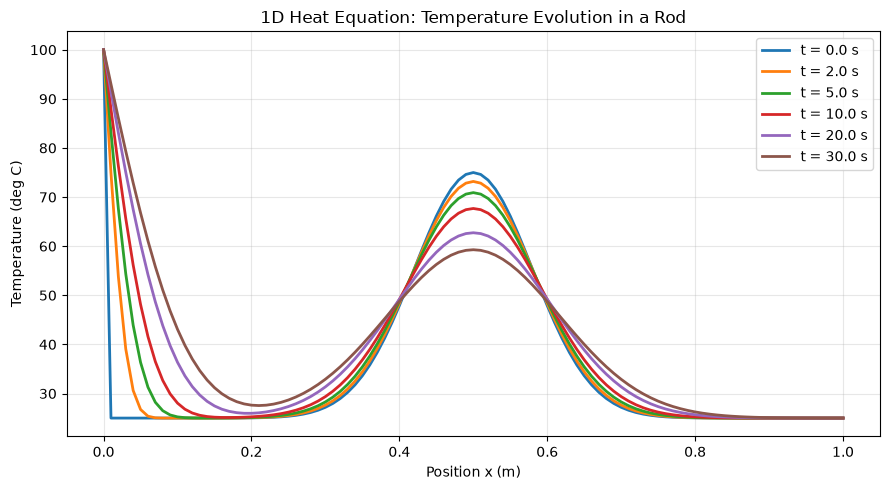

Final center temperature at x=L/2: 59.28 deg C


In [4]:
# Plot temperature profiles at selected times
plt.figure(figsize=(9, 5))
for ts in sorted(snapshots.keys()):
    plt.plot(x, snapshots[ts], label=f't = {ts:.1f} s', linewidth=2)
plt.title('1D Heat Equation: Temperature Evolution in a Rod')
plt.xlabel('Position x (m)')
plt.ylabel('Temperature (deg C)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
# Final profile summary
print(f'Final center temperature at x=L/2: {Tn[nx//2]:.2f} deg C')

## Comparing Low and High Thermal Diffusivity

This section compares two materials with different thermal diffusivities. Both start with the same localized hot spot, and we track how the heat spreads through the material.

- A low diffusivity means heat moves more slowly.
- A high diffusivity means heat moves more quickly and the hot spot becomes less concentrated.

This comparison is useful for thinking about reentry materials, although an actual thermal protection system would also depend on thickness, insulation, emissivity, and structural requirements.

In [5]:
def simulate_hotspot_diffusion(alpha_material, L=1.0, nx=201, t_final=120.0, T_ambient=300.0, probe_x=0.45):
    """Simulate 1D heat diffusion of an initial hotspot with fixed ambient boundaries."""
    x = np.linspace(0.0, L, nx)
    dx = x[1] - x[0]
    # Stability-safe time step for explicit scheme
    dt = 0.45 * dx**2 / alpha_material
    nt = int(np.ceil(t_final / dt))
    dt = t_final / nt
    r = alpha_material * dt / dx**2
    if r > 0.5:
        raise ValueError('Unstable setup encountered.')
    # Hotspot near leading-edge side (x ~ 0.15L)
    T = T_ambient + 1200.0 * np.exp(-((x - 0.15 * L) ** 2) / (2.0 * (0.05 * L) ** 2))
    T[0] = T_ambient
    T[-1] = T_ambient
    times = np.linspace(0.0, t_final, nt + 1)
    save_times = [0.0, 5.0, 10.0, 30.0, 60.0, 120.0]
    max_temp = np.zeros(nt + 1)
    probe_temp = np.zeros(nt + 1)
    probe_idx = int(probe_x * (nx - 1))
    max_temp[0] = np.max(T)
    probe_temp[0] = T[probe_idx]
    Tn = T.copy()
    history = [Tn.copy()]
    for n in range(1, nt + 1):
        Tnew = Tn.copy()
        Tnew[1:-1] = Tn[1:-1] + r * (Tn[2:] - 2.0 * Tn[1:-1] + Tn[:-2])
        Tnew[0] = T_ambient
        Tnew[-1] = T_ambient
        Tn = Tnew
        max_temp[n] = np.max(Tn)
        probe_temp[n] = Tn[probe_idx]
        history.append(Tn.copy())
    # Use the nearest simulated time for each requested snapshot
    snapshots = {}
    for ts in save_times:
        idx = int(np.argmin(np.abs(times - ts)))
        snapshots[ts] = history[idx]
    return {
        'x': x,
        'times': times,
        'snapshots': snapshots,
        'max_temp': max_temp,
        'probe_temp': probe_temp,
        'probe_x': probe_x,
        'alpha': alpha_material,
        'dt': dt,
        'r': r,
    }
# Thermal diffusivity values (m^2/s)
alpha_low = 2.0e-6
alpha_high = 1.2e-4  # higher-diffusivity case
low_case = simulate_hotspot_diffusion(alpha_low)
high_case = simulate_hotspot_diffusion(alpha_high)
print(f"Low diffusivity alpha = {alpha_low:.2e}, dt = {low_case['dt']:.3e}, r = {low_case['r']:.3f}")
print(f"High diffusivity alpha = {alpha_high:.2e}, dt = {high_case['dt']:.3e}, r = {high_case['r']:.3f}")

Low diffusivity alpha = 2.00e-06, dt = 5.455e+00, r = 0.436
High diffusivity alpha = 1.20e-04, dt = 9.375e-02, r = 0.450


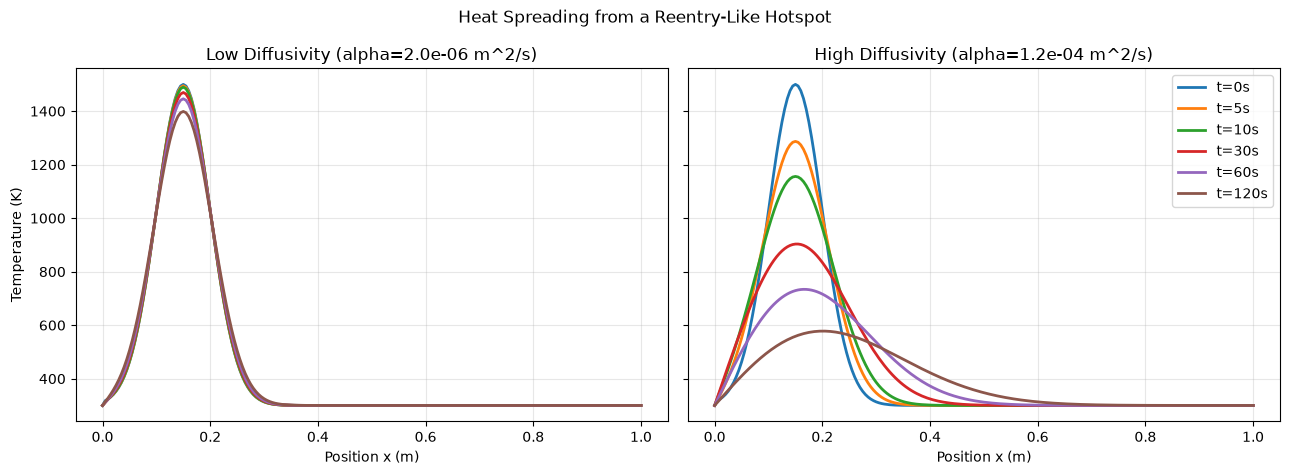

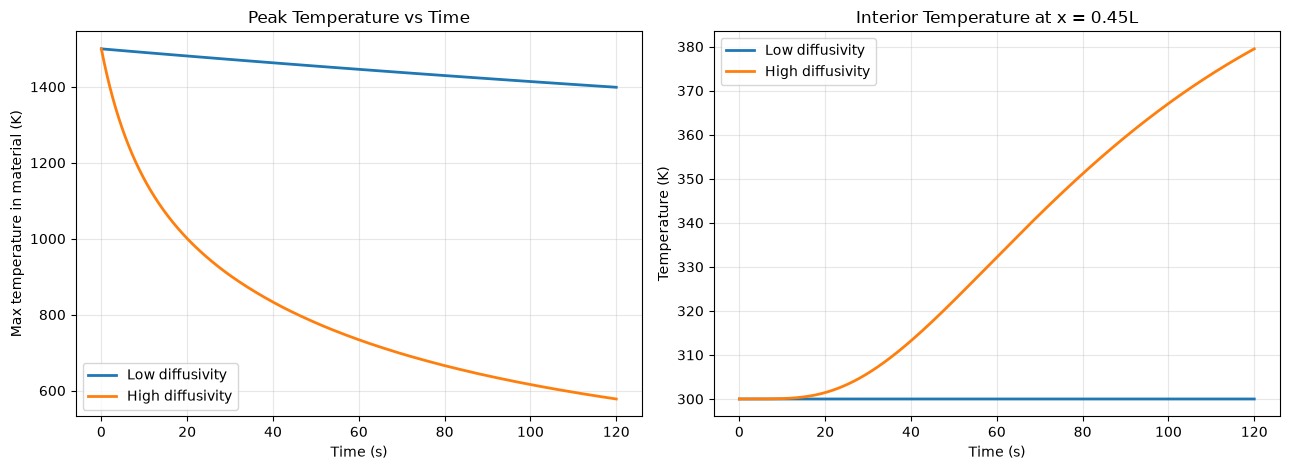

At t = 120 s:
  Low diffusivity max temp:  1398.81 K
  High diffusivity max temp: 577.93 K
  Low diffusivity T at x=0.45L:  300.00 K
  High diffusivity T at x=0.45L: 379.49 K


In [6]:
# Snapshot profiles: low vs high diffusivity
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
plot_times = [0.0, 5.0, 10.0, 30.0, 60.0, 120.0]
for t_plot in plot_times:
    axes[0].plot(low_case['x'], low_case['snapshots'][t_plot], linewidth=2, label=f't={t_plot:.0f}s')
    axes[1].plot(high_case['x'], high_case['snapshots'][t_plot], linewidth=2, label=f't={t_plot:.0f}s')
axes[0].set_title(f'Low Diffusivity (alpha={alpha_low:.1e} m^2/s)')
axes[1].set_title(f'High Diffusivity (alpha={alpha_high:.1e} m^2/s)')
for ax in axes:
    ax.set_xlabel('Position x (m)')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Temperature (K)')
axes[1].legend(loc='upper right')
plt.suptitle('Heat Spreading from a Reentry-Like Hotspot')
plt.tight_layout()
plt.show()
# Quantitative comparison metrics
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(low_case['times'], low_case['max_temp'], linewidth=2, label='Low diffusivity')
axes[0].plot(high_case['times'], high_case['max_temp'], linewidth=2, label='High diffusivity')
axes[0].set_title('Peak Temperature vs Time')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Max temperature in material (K)')
axes[0].grid(alpha=0.3)
axes[0].legend()
axes[1].plot(low_case['times'], low_case['probe_temp'], linewidth=2, label='Low diffusivity')
axes[1].plot(high_case['times'], high_case['probe_temp'], linewidth=2, label='High diffusivity')
axes[1].set_title(f"Interior Temperature at x = {low_case['probe_x']:.2f}L")
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Temperature (K)')
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()
print('At t = 120 s:')
print(f"  Low diffusivity max temp:  {low_case['max_temp'][-1]:.2f} K")
print(f"  High diffusivity max temp: {high_case['max_temp'][-1]:.2f} K")
print(f"  Low diffusivity T at x={low_case['probe_x']:.2f}L:  {low_case['probe_temp'][-1]:.2f} K")
print(f"  High diffusivity T at x={high_case['probe_x']:.2f}L: {high_case['probe_temp'][-1]:.2f} K")

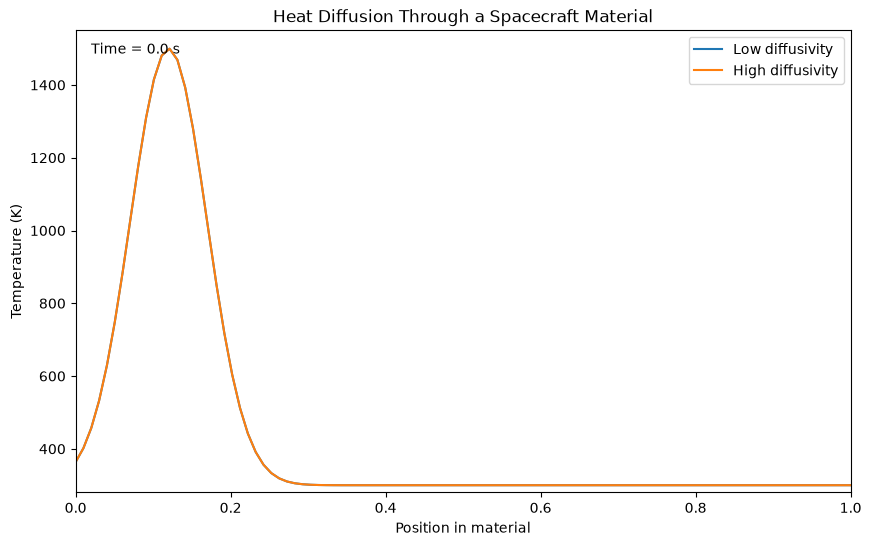

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
# Parameters
L = 1.0                 # thickness of material
nx = 100                # number of spatial grid points
dx = L / (nx - 1)
x = np.linspace(0, L, nx)
t_final = 120          # total simulation time (seconds)
# Two materials
alpha_low = 2e-6       # low thermal diffusivity
alpha_high = 1.2e-4    # high thermal diffusivity
# Stability condition for explicit method:
# r = alpha*dt/dx^2 <= 1/2
alpha_max = max(alpha_low, alpha_high)
dt = 0.4 * dx**2 / alpha_max
nt = int(t_final / dt)
# Initial temperature
T_initial = 300.0      # Kelvin
# Hotspot near outer surface
def initial_profile(x):
    return T_initial + 1200 * np.exp(-((x - 0.12) / 0.07)**2)
# Boundary conditions
# Left boundary: insulated
# Right boundary: insulated
# This keeps the demo simple and shows heat spreading clearly
def step_heat(u, alpha):
    r = alpha * dt / dx**2
    u_new = u.copy()
    # interior points
    for i in range(1, nx - 1):
        u_new[i] = u[i] + r * (u[i+1] - 2*u[i] + u[i-1])
    # insulated boundaries: du/dx = 0
    u_new[0] = u_new[1]
    u_new[-1] = u_new[-2]
    return u_new
# Initialize solutions
u_low = initial_profile(x)
u_high = initial_profile(x)
history_low = [u_low.copy()]
history_high = [u_high.copy()]
times = [0]
for n in range(nt):
    u_low = step_heat(u_low, alpha_low)
    u_high = step_heat(u_high, alpha_high)
    # save every few steps so animation is smoother and lighter
    if n % 20 == 0:
        history_low.append(u_low.copy())
        history_high.append(u_high.copy())
        times.append((n + 1) * dt)
history_low = np.array(history_low)
history_high = np.array(history_high)
# Plot animation
fig, ax = plt.subplots(figsize=(10, 6))
line1, = ax.plot(x, history_low[0], label='Low diffusivity')
line2, = ax.plot(x, history_high[0], label='High diffusivity')
ax.set_xlim(0, L)
ax.set_ylim(T_initial - 20, np.max(history_low[0]) + 50)
ax.set_xlabel("Position in material")
ax.set_ylabel("Temperature (K)")
ax.set_title("Heat Diffusion Through a Spacecraft Material")
ax.legend()
time_text = ax.text(0.02, 0.95, "", transform=ax.transAxes)
def update(frame):
    line1.set_ydata(history_low[frame])
    line2.set_ydata(history_high[frame])
    time_text.set_text(f"Time = {times[frame]:.1f} s")
    return line1, line2, time_text
ani = FuncAnimation(fig, update, frames=len(times), interval=120, blit=True)
plt.show()

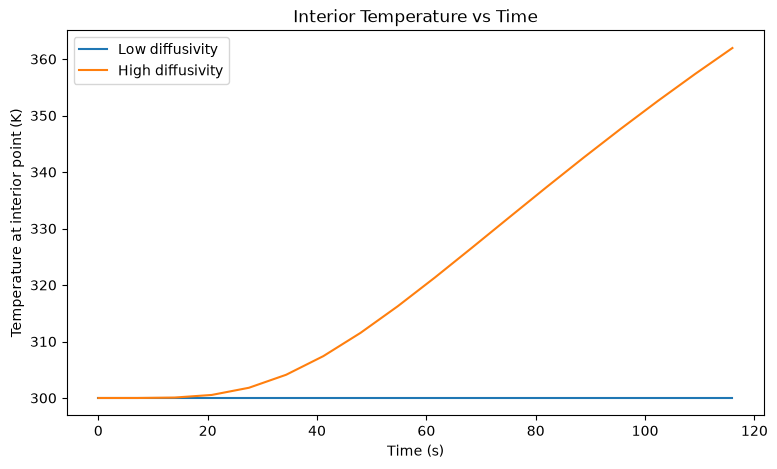

In [8]:
import matplotlib.pyplot as plt
interior_index = int(0.45 * (nx - 1))
plt.figure(figsize=(9, 5))
plt.plot(times, history_low[:, interior_index], label="Low diffusivity")
plt.plot(times, history_high[:, interior_index], label="High diffusivity")
plt.xlabel("Time (s)")
plt.ylabel("Temperature at interior point (K)")
plt.title("Interior Temperature vs Time")
plt.legend()
plt.show()

# Spacecraft Wall: A Thermal Diffusivity Comparison

## Setup

I model a spacecraft wall with a hot spot near its outer surface and compare two materials.

- The wall extends from $x=0$ to $x=L$.
- The initial hot spot represents external heating.
- Thermal diffusivity $\alpha$ controls how quickly heat spreads.

The main question is whether spreading the heat quickly helps keep the inside of the wall cooler.

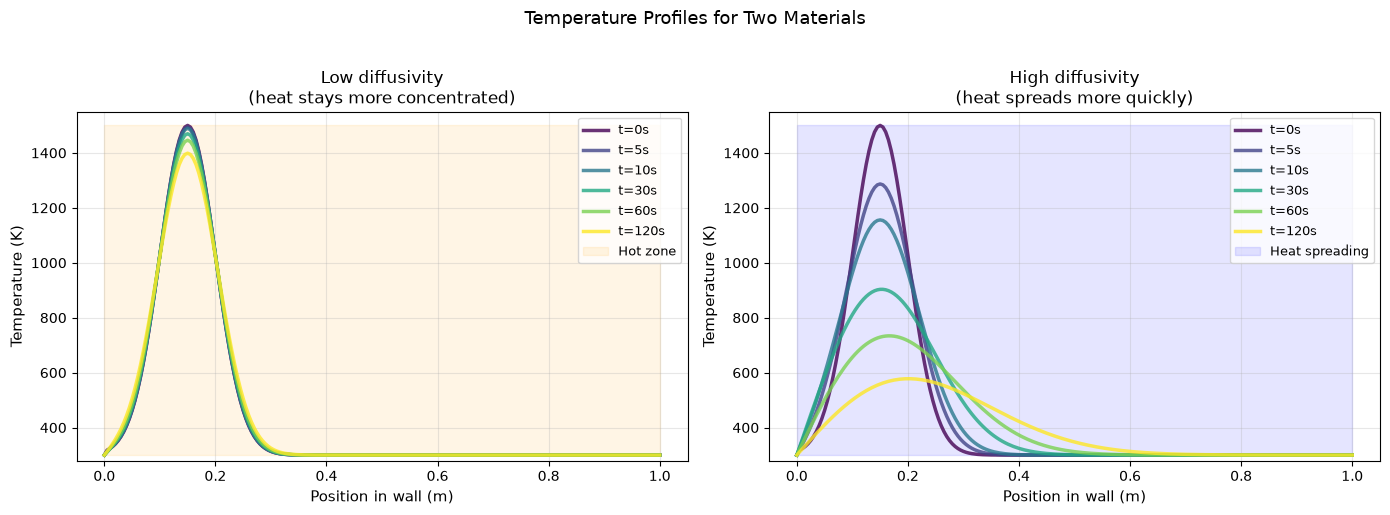

Low diffusivity keeps the hot spot more localized.
High diffusivity spreads the heat farther into the wall.


In [9]:
# Compare temperature profiles at several times
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
viz_times = [0.0, 5.0, 10.0, 30.0, 60.0, 120.0]
colors = plt.cm.viridis(np.linspace(0, 1, len(viz_times)))
for i, t_plot in enumerate(viz_times):
    axes[0].plot(low_case['x'], low_case['snapshots'][t_plot],
                 linewidth=2.5, color=colors[i], label=f't={t_plot:.0f}s', alpha=0.8)
    axes[1].plot(high_case['x'], high_case['snapshots'][t_plot],
                 linewidth=2.5, color=colors[i], label=f't={t_plot:.0f}s', alpha=0.8)
axes[0].fill_between(low_case['x'], 300, 1500, alpha=0.1, color='orange', label='Hot zone')
axes[0].set_title('Low diffusivity\n(heat stays more concentrated)', fontsize=12)
axes[0].set_xlabel('Position in wall (m)', fontsize=11)
axes[0].set_ylabel('Temperature (K)', fontsize=11)
axes[0].set_ylim(280, 1550)
axes[0].grid(alpha=0.3)
axes[0].legend(loc='upper right', fontsize=9)
axes[1].fill_between(high_case['x'], 300, 1500, alpha=0.1, color='blue', label='Heat spreading')
axes[1].set_title('High diffusivity\n(heat spreads more quickly)', fontsize=12)
axes[1].set_xlabel('Position in wall (m)', fontsize=11)
axes[1].set_ylabel('Temperature (K)', fontsize=11)
axes[1].set_ylim(280, 1550)
axes[1].grid(alpha=0.3)
axes[1].legend(loc='upper right', fontsize=9)
plt.suptitle('Temperature Profiles for Two Materials', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
print('Low diffusivity keeps the hot spot more localized.')
print('High diffusivity spreads the heat farther into the wall.')

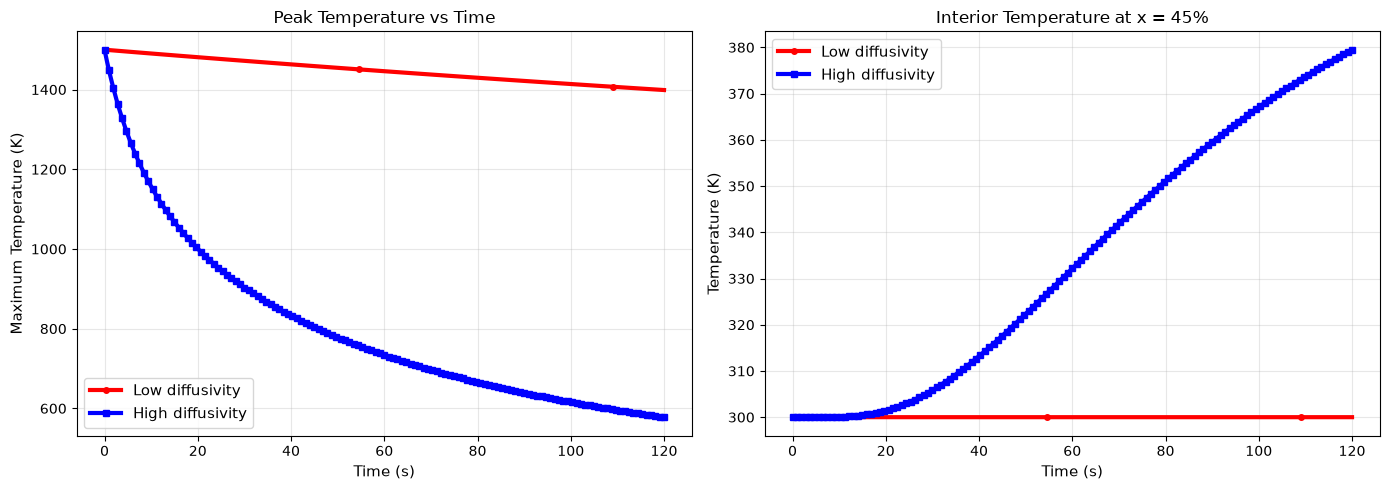

After 120 seconds:
  Low diffusivity peak temperature:  1399 K
  High diffusivity peak temperature: 578 K
  Low diffusivity interior temperature:  300 K
  High diffusivity interior temperature: 379 K

High diffusivity lowers the peak temperature more quickly.
Low diffusivity delays heating at the interior point.


In [10]:
# Compare the peak temperature with the temperature at an interior point
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(low_case['times'], low_case['max_temp'], linewidth=3,
             label='Low diffusivity', color='red', marker='o', markersize=4, markevery=10)
axes[0].plot(high_case['times'], high_case['max_temp'], linewidth=3,
             label='High diffusivity', color='blue', marker='s', markersize=4, markevery=10)
axes[0].set_title('Peak Temperature vs Time', fontsize=12)
axes[0].set_xlabel('Time (s)', fontsize=11)
axes[0].set_ylabel('Maximum Temperature (K)', fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=11)
probe_x = low_case['probe_x']
axes[1].plot(low_case['times'], low_case['probe_temp'], linewidth=3,
            label='Low diffusivity', color='red', marker='o', markersize=4, markevery=10)
axes[1].plot(high_case['times'], high_case['probe_temp'], linewidth=3,
            label='High diffusivity', color='blue', marker='s', markersize=4, markevery=10)
axes[1].set_title(f'Interior Temperature at x = {probe_x:.0%}', fontsize=12)
axes[1].set_xlabel('Time (s)', fontsize=11)
axes[1].set_ylabel('Temperature (K)', fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=11)
plt.tight_layout()
plt.show()
print(f'After {t_final} seconds:')
print(f'  Low diffusivity peak temperature:  {low_case["max_temp"][-1]:.0f} K')
print(f'  High diffusivity peak temperature: {high_case["max_temp"][-1]:.0f} K')
print(f'  Low diffusivity interior temperature:  {low_case["probe_temp"][-1]:.0f} K')
print(f'  High diffusivity interior temperature: {high_case["probe_temp"][-1]:.0f} K')
print('\nHigh diffusivity lowers the peak temperature more quickly.')
print('Low diffusivity delays heating at the interior point.')

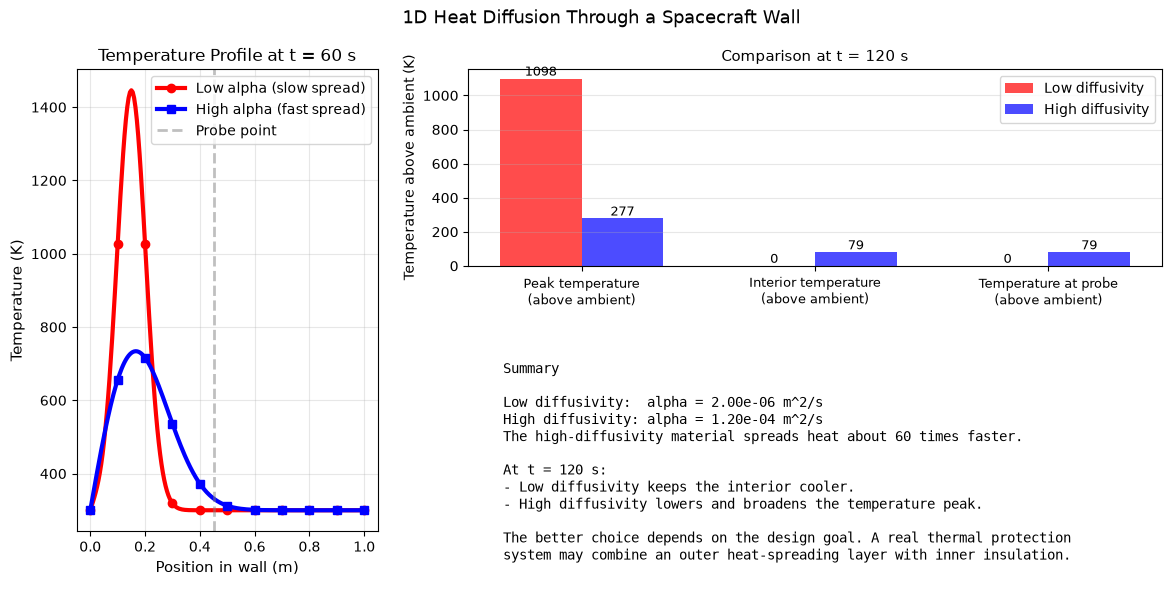

At t = 120 s:
  Low diffusivity peak temperature:  1399 K
  High diffusivity peak temperature: 578 K
  Low diffusivity interior temperature:  300 K
  High diffusivity interior temperature: 379 K


In [11]:
# Summary of the two material cases
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)
ax_main = fig.add_subplot(gs[:, 0])
t_snapshot = 60.0
ax_main.plot(low_case['x'], low_case['snapshots'][t_snapshot], linewidth=3,
             color='red', label='Low alpha (slow spread)', marker='o', markersize=6, markevery=20)
ax_main.plot(high_case['x'], high_case['snapshots'][t_snapshot], linewidth=3,
             color='blue', label='High alpha (fast spread)', marker='s', markersize=6, markevery=20)
ax_main.axvline(high_case['probe_x'], color='gray', linestyle='--', linewidth=2, alpha=0.5, label='Probe point')
ax_main.set_xlabel('Position in wall (m)', fontsize=11)
ax_main.set_ylabel('Temperature (K)', fontsize=11)
ax_main.set_title(f'Temperature Profile at t = {t_snapshot:.0f} s', fontsize=12)
ax_main.grid(alpha=0.3)
ax_main.legend(fontsize=10, loc='upper right')
ax1 = fig.add_subplot(gs[0, 1:])
metrics = ['Peak temperature\n(above ambient)', 'Interior temperature\n(above ambient)', 'Temperature at probe\n(above ambient)']
low_vals = [
    low_case['max_temp'][-1] - 300,
    low_case['probe_temp'][-1] - 300,
    low_case['probe_temp'][-1] - 300
]
high_vals = [
    high_case['max_temp'][-1] - 300,
    high_case['probe_temp'][-1] - 300,
    high_case['probe_temp'][-1] - 300
]
x_pos = np.arange(len(metrics))
width = 0.35
bars1 = ax1.bar(x_pos - width / 2, low_vals, width, label='Low diffusivity', color='red', alpha=0.7)
bars2 = ax1.bar(x_pos + width / 2, high_vals, width, label='High diffusivity', color='blue', alpha=0.7)
ax1.set_ylabel('Temperature above ambient (K)', fontsize=10)
ax1.set_title('Comparison at t = 120 s', fontsize=11)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(metrics, fontsize=9)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3, axis='y')
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width() / 2., height,
                 f'{int(height)}', ha='center', va='bottom', fontsize=9)
ax2 = fig.add_subplot(gs[1, 1:])
ax2.axis('off')
summary_text = f"""
Summary
Low diffusivity:  alpha = {alpha_low:.2e} m^2/s
High diffusivity: alpha = {alpha_high:.2e} m^2/s
The high-diffusivity material spreads heat about {alpha_high / alpha_low:.0f} times faster.
At t = 120 s:
- Low diffusivity keeps the interior cooler.
- High diffusivity lowers and broadens the temperature peak.
The better choice depends on the design goal. A real thermal protection
system may combine an outer heat-spreading layer with inner insulation.
"""
ax2.text(0.05, 0.95, summary_text, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace')
plt.suptitle('1D Heat Diffusion Through a Spacecraft Wall', fontsize=13, y=0.98)
plt.show()
print(f'At t = {t_final} s:')
print(f'  Low diffusivity peak temperature:  {low_case["max_temp"][-1]:.0f} K')
print(f'  High diffusivity peak temperature: {high_case["max_temp"][-1]:.0f} K')
print(f'  Low diffusivity interior temperature:  {low_case["probe_temp"][-1]:.0f} K')
print(f'  High diffusivity interior temperature: {high_case["probe_temp"][-1]:.0f} K')

## Try changing the parameters

Run the simulation cells first, then change one parameter at a time and rerun the relevant cells.

1. Change the wall thickness by editing `L` in `simulate_hotspot_diffusion`.
   - A thicker wall gives the heat farther to travel.
2. Change the initial heating by editing `1200.0` in the initial temperature profile.
3. Add a third material by trying an intermediate value of `alpha`.
4. Change `t_final` to look at earlier or later behavior.

The plots should show the tradeoff clearly: high diffusivity spreads heat more quickly, while low diffusivity delays the temperature rise farther inside the wall.